# บทที่ 4 — วัดระยะด้วยกล้องตัวเดียว (ไม่ใช้เซนเซอร์ระยะเลย!)

🎯 เป้าหมาย: เข้าใจว่าทำไม "ขนาดวัตถุในภาพ" บอกระยะได้ และลองคำนวณ calibrate ด้วยตัวเอง

## 1. หลักการ: วัตถุยิ่งไกล ยิ่งเห็นเล็กลง (แบบมีสูตร ไม่ใช่แค่ความรู้สึก)

หลักการนี้เรียกว่า **สามเหลี่ยมคล้าย (similar triangles)** — เป็นเรขาคณิตม.ต้นล้วนๆ ไม่มีอะไรซับซ้อน
ลองดูภาพประกอบ: แสงจากวัตถุสูง `H` ที่ระยะ `D` วิ่งผ่านเลนส์กล้องไปตกที่ระนาบภาพ กลายเป็นภาพสูง `h`

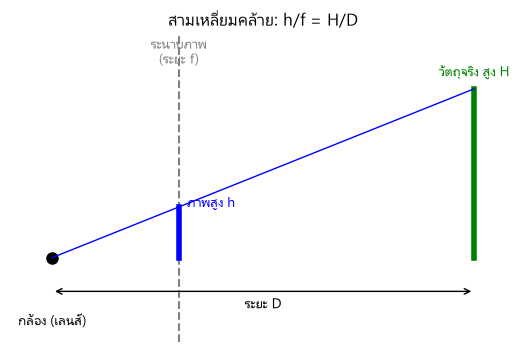

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Leelawadee UI"   # ฟอนต์นี้รองรับภาษาไทย กันตัวอักษรไทยในกราฟกลายเป็นกล่องว่าง

f, D, H = 3, 10, 4        # ตัวเลขสมมติไว้วาดรูปให้เห็นสัดส่วน (หน่วยไม่สำคัญ แค่ให้เห็นภาพ)
h = H * f / D              # ภาพยิ่งเล็กถ้า D ยิ่งมาก (สูตรสามเหลี่ยมคล้าย)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(0, 0, "ko", markersize=8)
ax.text(0, -1.6, "กล้อง (เลนส์)", ha="center")

ax.axvline(f, color="gray", linestyle="--")
ax.text(f, H + 0.6, "ระนาบภาพ\n(ระยะ f)", ha="center", color="gray")

ax.plot([D, D], [0, H], "g-", linewidth=4)
ax.text(D, H + 0.3, "วัตถุจริง สูง H", color="green", ha="center")

ax.plot([0, D], [0, H], "b-", linewidth=1)          # เส้นแสงจากยอดวัตถุผ่านเลนส์
ax.plot([f, f], [0, h], "b-", linewidth=4)
ax.text(f + 0.2, h, "ภาพสูง h", color="blue")

ax.annotate("", xy=(D, -0.8), xytext=(0, -0.8), arrowprops=dict(arrowstyle="<->"))
ax.text(D / 2, -1.2, "ระยะ D", ha="center")

ax.set_xlim(-1, D + 1); ax.set_ylim(-2, H + 1.3)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("สามเหลี่ยมคล้าย: h/f = H/D")
plt.show()

## 2. จากรูปสามเหลี่ยมคล้าย ได้สูตร

จากรูป: สามเหลี่ยมเล็ก (f, h) กับสามเหลี่ยมใหญ่ (D, H) มีสัดส่วนเท่ากัน (คล้ายกัน):

$$ \frac{h}{f} = \frac{H}{D} \quad\Longrightarrow\quad D = \frac{f \times H}{h} $$

พูดเป็นภาษาคน: **ระยะ = (focal length × ขนาดจริงของวัตถุ) ÷ ขนาดที่เห็นในภาพ**

ปัญหาคือเราไม่รู้ค่า `f` (focal length ของกล้องเรา หน่วยเป็น pixel) ล่วงหน้า
→ ต้อง **calibrate** หามันก่อน 1 ครั้ง โดยวางวัตถุที่ระยะที่รู้ค่าแน่นอน (วัดด้วยตลับเมตร) แล้วย้อนสูตรกลับ:

$$ f = \frac{h \times D}{H} $$

## 3. ลองมือ: จำลองสถานการณ์ทั้งหมดด้วยตัวเลขที่ควบคุมได้

ในชีวิตจริงเราไม่รู้ค่า focal length ที่แท้จริงของกล้อง — แต่ในบทเรียนนี้ **เราจะแอบรู้ไว้ก่อน**
เพื่อเช็คว่าวิธี calibrate ที่เขียนขึ้นมาเองนั้น "ได้คำตอบถูกจริง" หรือไม่ (มีเฉลยให้ตรวจสอบตัวเอง)

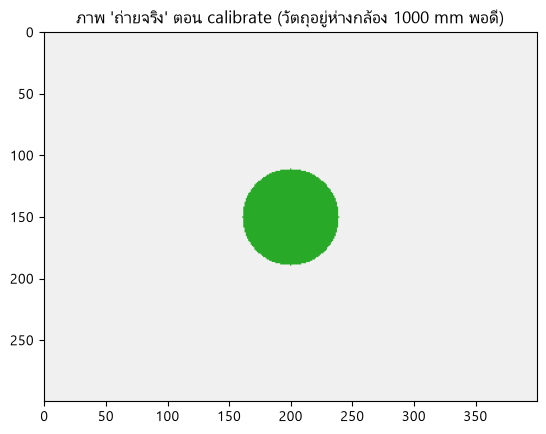

In [2]:
import cv2
import numpy as np

_SECRET_FOCAL_PX = 800.0   # ค่าจริงของกล้องสมมติ (ในชีวิตจริงเราไม่มีทางรู้ค่านี้ล่วงหน้า!)

def capture_object_at_distance(dist_mm, real_width_mm=100):
    # สร้างภาพวัตถุกลมสีเขียว ขนาดในภาพคำนวณจากสูตรสามเหลี่ยมคล้ายจริงๆ (มีสัญญาณรบกวนนิดหน่อยแบบกล้องจริง)
    true_w_px = _SECRET_FOCAL_PX * real_width_mm / dist_mm
    true_w_px *= np.random.uniform(0.97, 1.03)   # จำลอง noise เล็กน้อยแบบกล้องจริง (ไม่มีอะไร perfect 100%)
    img = np.full((300, 400, 3), (240, 240, 240), np.uint8)
    cv2.circle(img, (200, 150), int(true_w_px / 2), (40, 170, 40), -1)
    return img


np.random.seed(1)
calib_image = capture_object_at_distance(dist_mm=1000, real_width_mm=100)
plt.imshow(cv2.cvtColor(calib_image, cv2.COLOR_BGR2RGB))
plt.title("ภาพ 'ถ่ายจริง' ตอน calibrate (วัตถุอยู่ห่างกล้อง 1000 mm พอดี)")
plt.show()

## 4. หาความกว้างวัตถุในภาพ (pixel) — ใช้เทคนิคจากบทที่ 3 เป๊ะ

In [3]:
def find_object_width_px(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([35, 80, 60]), np.array([85, 255, 255]))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_blob = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_blob)
    return w


w_px = find_object_width_px(calib_image)
print(f"วัดความกว้างวัตถุในภาพได้ {w_px} px")

วัดความกว้างวัตถุในภาพได้ 79 px


## 5. Calibrate: หาค่า focal length

ตอนนี้รู้แล้วว่า: ระยะจริง (วัดด้วยตลับเมตร) = 1000 mm, ขนาดจริงวัตถุ = 100 mm, ขนาดในภาพ = `w_px`
แทนสูตร `f = h × D / H` ได้เลย

In [4]:
DIST_CALIB_MM = 1000
REAL_WIDTH_MM = 100

focal_px = w_px * DIST_CALIB_MM / REAL_WIDTH_MM
print(f"FOCAL_PX ที่ calibrate ได้ = {focal_px:.1f}")
print(f"(ค่าลับจริงคือ {_SECRET_FOCAL_PX} — ใกล้เคียงกันมาก แม้จะมี noise ปนอยู่ก็ตาม)")

FOCAL_PX ที่ calibrate ได้ = 790.0
(ค่าลับจริงคือ 800.0 — ใกล้เคียงกันมาก แม้จะมี noise ปนอยู่ก็ตาม)


## 6. ทดสอบ: เอา focal ที่ calibrate ได้ไปทำนายระยะของภาพใหม่ (ที่ไม่เคยเห็นมาก่อน)

นี่คือด่านทดสอบจริง — เราจะ "ถ่ายภาพใหม่" ที่ระยะอื่น (โปรแกรมรู้คำตอบลับๆ แต่เราต้องทำนายโดยไม่ดูมัน)
แล้วเทียบว่าทำนายได้แม่นแค่ไหน

In [5]:
def predict_distance(img, focal_px, real_width_mm=100):
    w = find_object_width_px(img)
    return focal_px * real_width_mm / w


_SECRET_TEST_DIST = 1500   # ระยะจริงของภาพทดสอบ (แกล้งทำเป็นไม่รู้ก่อน)
test_image = capture_object_at_distance(_SECRET_TEST_DIST, real_width_mm=100)

predicted_distance = predict_distance(test_image, focal_px)
error_pct = abs(predicted_distance - _SECRET_TEST_DIST) / _SECRET_TEST_DIST * 100

print(f"ทำนายระยะได้ {predicted_distance:.0f} mm")
print(f"ระยะจริง (เฉลยที่ซ่อนไว้) = {_SECRET_TEST_DIST} mm")
print(f"คลาดเคลื่อน {error_pct:.1f}%")

ทำนายระยะได้ 1436 mm
ระยะจริง (เฉลยที่ซ่อนไว้) = 1500 mm
คลาดเคลื่อน 4.2%


ถ้าคลาดเคลื่อนแค่ไม่กี่ % แปลว่าวิธี calibrate ใช้ได้ผลจริง! นี่คือขั้นตอนเดียวกับที่ `tools/calibrate_focal.py` ในโปรเจคจริงทำ
ต่างกันแค่ของจริงต้องเอาตลับเมตรไปวัดระยะเองแทนที่จะให้โปรแกรมสุ่มให้

## 🧪 แบบฝึกหัดท้ายบท

โจทย์: ลองเปลี่ยน `_SECRET_TEST_DIST` เป็นค่าอื่นๆ (เช่น 800, 1200, 2000) แล้วดูว่า error % เปลี่ยนไปไหม
สังเกตว่าระยะใกล้ calibration point (1000mm) มัก error น้อยกว่าระยะที่ห่างออกไปมากๆ หรือไม่?

เขียนโค้ด loop ทดสอบหลายระยะพร้อมกันในเซลล์ถัดไป

In [6]:
for d in [800, 1000, 1200, 1500, 2000, 2500]:
    img = capture_object_at_distance(d, real_width_mm=100)
    pred = predict_distance(img, focal_px)
    err = abs(pred - d) / d * 100
    print(f"ระยะจริง {d:5d} mm  →  ทำนาย {pred:7.1f} mm  (error {err:4.1f}%)")

ระยะจริง   800 mm  →  ทำนาย   814.4 mm  (error  1.8%)
ระยะจริง  1000 mm  →  ทำนาย  1000.0 mm  (error  0.0%)
ระยะจริง  1200 mm  →  ทำนาย  1215.4 mm  (error  1.3%)
ระยะจริง  1500 mm  →  ทำนาย  1490.6 mm  (error  0.6%)
ระยะจริง  2000 mm  →  ทำนาย  2025.6 mm  (error  1.3%)
ระยะจริง  2500 mm  →  ทำนาย  2548.4 mm  (error  1.9%)


<details><summary>👉 สังเกตอะไรได้บ้าง?</summary>

error % ควรใกล้เคียงกันในทุกระยะ (ไม่ได้แปรผันตามระยะห่างจากจุด calibrate มากนัก) เพราะ noise ที่ใส่ไว้เป็นแบบสุ่ม±3% คงที่
แต่ใน**ของจริง** ปัจจัยอื่นจะเข้ามาแทรกมากขึ้นตามระยะไกล เช่น auto-focus กล้องเพี้ยนเอง, ความละเอียดภาพจำกัด (วัตถุไกลมากมีแค่ไม่กี่ pixel วัดได้ไม่แม่น)
— นี่คือเหตุผลที่โปรเจคจริงต้อง **ล็อก focus กล้องก่อน calibrate เสมอ** (อธิบายไว้ใน `docs/คู่มือโค้ด-อ่านก่อน.md`)
</details>

---
## ✅ สรุปบทนี้

| เรื่อง | สรุปสั้นๆ |
|---|---|
| สามเหลี่ยมคล้าย | วัตถุไกล → ภาพเล็กลง เป็นสัดส่วนผกผันกับระยะ |
| สูตรวัดระยะ | `ระยะ = focal_px × ขนาดจริง ÷ ขนาดในภาพ(px)` |
| Calibrate | วัดที่ระยะที่รู้ค่า แล้วย้อนสูตรหา `focal_px` |
| ต้องล็อก focus ก่อน | auto-focus เปลี่ยน = focal เปลี่ยน = ค่าที่ calibrate ไว้ใช้ไม่ได้ |

➡️ **ไปต่อ:** เปิด `05_yolo_intro.ipynb` — บทสุดท้าย ลองให้ AI ช่วยตรวจจับวัตถุแทนการไล่สีเอง